## Importing the Library

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GlobalAveragePooling2D,Input, BatchNormalization, Dense,Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
import seaborn as sns
import gc

2025-07-29 09:34:26.832806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753781667.020981      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753781667.079993      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Dataset generator

In [2]:
def build_dataset_cnn(path, img_size=(224,224)):
    import os
    import cv2
    import numpy as np
    from tensorflow.keras.preprocessing.image import ImageDataGenerator
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    X_real, X_fake = [], []
    folders = sorted(os.listdir(path))

    if len(folders) < 3:
        print("Error: Need at least 3 folders for this operation.")
        return None

    fake_folders = [folders[0], folders[2]]
    real_folder = folders[1]

    for folder in folders[1:]:
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue

        label = 0 if folder in fake_folders else (1 if folder == real_folder else None)
        if label is None:
            continue

        # 🔶 Limit number of images based on folder type
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.tif'))]

        for file in files:
            img_path = os.path.join(folder_path, file)
            I1 = cv2.imread(img_path)
            if I1 is None:
                continue

            I1 = cv2.resize(I1, (224,224))
            I1 = cv2.cvtColor(I1, cv2.COLOR_BGR2RGB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            channels = [clahe.apply(c) for c in cv2.split(I1)]
            I1 = cv2.merge(channels)
            
            # 🔶 Stronger texture enhancement
            channels = cv2.split(I1)
            sharpened_channels = []
            for c in channels:
                for _ in range(3):  # two unsharp passes
                    blur = cv2.GaussianBlur(c, (5,5), 0)
                    c = cv2.addWeighted(c, 2.0, blur, -1.0, 0)
                sharpened_channels.append(c)
            I1 = cv2.merge(sharpened_channels)

            if label == 1:
                X_real.append(I1)
            else:
                X_fake.append(I1)

    X_real = np.array(X_real, dtype='float32')
    X_fake = np.array(X_fake, dtype='float32')

    # 🔶 Augment fake images in batches if needed
    needed = len(X_real) - len(X_fake)
    if needed > 0:
        datagen = ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
        batch_size = min(needed, 64)
        aug_iter = datagen.flow(X_fake, batch_size=batch_size, shuffle=True)
        augmented_images = []
        generated = 0
        while generated < needed:
            batch = next(aug_iter)
            augmented_images.append(batch)
            generated += batch.shape[0]
        augmented_images = np.concatenate(augmented_images, axis=0)[:needed]
        X_fake = np.concatenate([X_fake, augmented_images], axis=0)

    # 🔶 Create labels
    y_real = np.ones(len(X_real))
    y_fake = np.zeros(len(X_fake))

    # 🔶 Combine and preprocess
    X = np.concatenate([X_real, X_fake], axis=0)
    y = np.concatenate([y_real, y_fake], axis=0)

    print("Dataset shapes:", X.shape, y.shape)

    X = preprocess_input(X)

    return X, y


## Generating the dataset

In [3]:
X,Y=build_dataset_cnn(r"/kaggle/input/hand-liveness-dataset-3-classes/Hand Liveness Dataset (3 classes)")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42,stratify=Y)
del X
del Y
gc.collect()

Dataset shapes: (17834, 224, 224, 3) (17834,)


0

In [4]:
inputs = Input(shape=(224, 224, 3))

base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)
for layer in base_model.layers:
    layer.trainable = False  # Set to True if fine-tuning entire model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

# Create final model
model = Model(inputs=inputs, outputs=outputs)
model.summary()

/tmp/ipykernel_19/984790318.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)
I0000 00:00:1753782716.367901      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise_BN 

 Total params: 2,345,409 (8.95 MB)

 Trainable params: 84,737 (331.00 KB)

 Non-trainable params: 2,260,672 (8.62 MB)

## Model Training

In [5]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy',metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_accuracy',patience=20,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',factor=0.5,patience=5,min_lr=1e-7,verbose=1)
history = model.fit(X_train, Y_train,validation_split=0.2,epochs=100,batch_size=32,callbacks=[early_stop, reduce_lr],verbose=2)

print(f"Best Training Accuracy: {max(history.history['accuracy'])*100:.2f}%")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/100


I0000 00:00:1753782745.175620      61 service.cc:148] XLA service 0x7a304810fd50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753782745.176205      61 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753782746.248580      61 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1753782750.455979      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


357/357 - 39s - 108ms/step - accuracy: 0.9157 - loss: 0.2137 - val_accuracy: 0.9681 - val_loss: 0.0958 - learning_rate: 1.0000e-04
Epoch 2/100
357/357 - 10s - 29ms/step - accuracy: 0.9642 - loss: 0.1032 - val_accuracy: 0.9800 - val_loss: 0.0628 - learning_rate: 1.0000e-04
Epoch 3/100
357/357 - 10s - 29ms/step - accuracy: 0.9751 - loss: 0.0784 - val_accuracy: 0.9842 - val_loss: 0.0507 - learning_rate: 1.0000e-04
Epoch 4/100
357/357 - 10s - 29ms/step - accuracy: 0.9783 - loss: 0.0683 - val_accuracy: 0.9856 - val_loss: 0.0457 - learning_rate: 1.0000e-04
Epoch 5/100
357/357 - 10s - 29ms/step - accuracy: 0.9828 - loss: 0.0554 - val_accuracy: 0.9870 - val_loss: 0.0400 - learning_rate: 1.0000e-04
Epoch 6/100
357/357 - 10s - 29ms/step - accuracy: 0.9827 - loss: 0.0507 - val_accuracy: 0.9881 - val_loss: 0.0362 - learning_rate: 1.0000e-04
Epoch 7/100
357/357 - 10s - 29ms/step - accuracy: 0.9844 - loss: 0.0481 - val_accuracy: 0.9888 - val_loss: 0.0344 - learning_rate: 1.0000e-04
Epoch 8/100
357/3

## Fine-Tuning the Model

In [6]:
for layer in model.layers[-60:]:
    layer.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),loss='binary_crossentropy',metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_accuracy',patience=20,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',factor=0.5,patience=5,min_lr=1e-7,verbose=1)
history = model.fit(X_train, Y_train,validation_split=0.2,epochs=100,batch_size=32,callbacks=[early_stop, reduce_lr],verbose=2)

print(f"Best Training Accuracy: {max(history.history['accuracy'])*100:.2f}%")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Epoch 1/100


E0000 00:00:1753783166.461250      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753783166.658770      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753783186.800752      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1753783187.000034      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


357/357 - 60s - 169ms/step - accuracy: 0.9594 - loss: 0.1152 - val_accuracy: 0.9856 - val_loss: 0.0341 - learning_rate: 1.0000e-05
Epoch 2/100
357/357 - 14s - 40ms/step - accuracy: 0.9807 - loss: 0.0528 - val_accuracy: 0.9919 - val_loss: 0.0244 - learning_rate: 1.0000e-05
Epoch 3/100
357/357 - 14s - 40ms/step - accuracy: 0.9879 - loss: 0.0352 - val_accuracy: 0.9926 - val_loss: 0.0213 - learning_rate: 1.0000e-05
Epoch 4/100
357/357 - 14s - 39ms/step - accuracy: 0.9923 - loss: 0.0245 - val_accuracy: 0.9965 - val_loss: 0.0164 - learning_rate: 1.0000e-05
Epoch 5/100
357/357 - 14s - 40ms/step - accuracy: 0.9926 - loss: 0.0218 - val_accuracy: 0.9947 - val_loss: 0.0209 - learning_rate: 1.0000e-05
Epoch 6/100
357/357 - 14s - 40ms/step - accuracy: 0.9947 - loss: 0.0176 - val_accuracy: 0.9968 - val_loss: 0.0142 - learning_rate: 1.0000e-05
Epoch 7/100
357/357 - 14s - 40ms/step - accuracy: 0.9954 - loss: 0.0152 - val_accuracy: 0.9975 - val_loss: 0.0118 - learning_rate: 1.0000e-05
Epoch 8/100
357/3

## Testing the Model

112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step


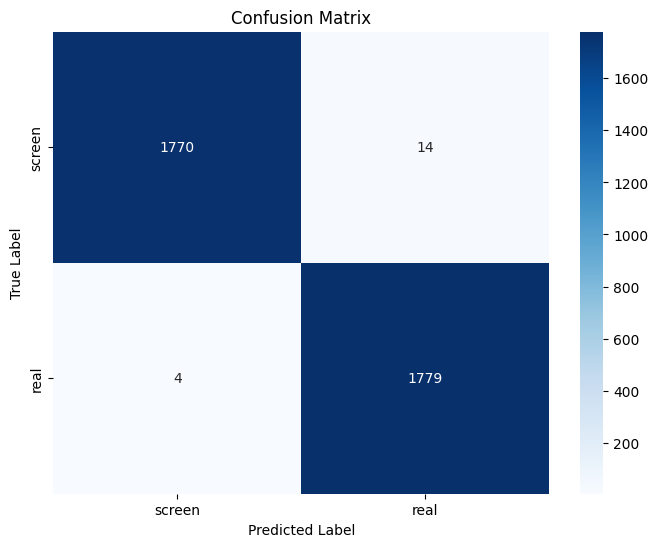

Test Accuracy: 99.49537426408746
              precision    recall  f1-score   support

      screen       1.00      0.99      0.99      1784
        real       0.99      1.00      0.99      1783

    accuracy                           0.99      3567
   macro avg       0.99      0.99      0.99      3567
weighted avg       0.99      0.99      0.99      3567



In [7]:
Y_pred_probs = model.predict(X_test)
Y_pred = (Y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(Y_test, Y_pred)
labels = ['screen', 'real']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

test_accuracy = accuracy_score(Y_test, Y_pred)
print("Test Accuracy:", test_accuracy*100)
print(classification_report(Y_test, Y_pred, target_names=labels))


## Saving the Model

In [8]:
model.save('screen_fingerprint_classifier.h5')